<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/PL8_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prelab 8.3 Classifying Air-tight Vacuum and Air-leak Vacuum Data using Autoencoders for Anomaly Detection: Y and Z-axis

In [5]:
# Let's check the installed tensorflow version
import tensorflow as tf

print('TensorFlow Version is', tf.__version__)

TensorFlow Version is 2.19.0


In [6]:
# required Python packages for this colab
!pip install matplotlib
!pip install pandas
!pip install scipy
!pip install scikit-learn

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.fftpack
from tensorflow import keras

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

In [8]:
# Copying raw data from github dataset file
url = 'https://raw.githubusercontent.com/purduelamm/purdue_me597_iiot/main/lab/lab8/Prelab8_data.csv'
#df is the variable where the data is stored
df = pd.read_csv(url)

#Data selection
# X-axis: 'Xacc array [m/s2]'
# Y-axis: 'Yacc array [m/s2]'
# Z-axis: 'Zacc array [m/s2]'
# If you want to use x-axis (X-axis),
# AXIS = 'Xacc array [m/s2]'
AXIS = 'Yacc array [m/s2]' #Pick and write the axis you want to work <-----------------------------------------------------------------------------

#Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat([df['Condition'],df[AXIS].str.split(' ', expand=True).astype(float)], axis=1)
ds = df_new.copy()
#Converting the Classifier into binary values
ds.loc[df['Condition'] == 'Vacuuming', 'Status'] = 1
ds.loc[df['Condition'] == 'Air_leakage', 'Status'] = 0
ds.drop('Condition', axis=1, inplace=True)

#Data transformation

raw_data = ds.values
# The last element contains the labels
labels = raw_data[:, -1]

# The other data points are the vacuum accelerometer data
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)
#Normalizing the values of the dataset
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)
#Splitting the dataset based on classification: train_labels: Vacuuming, ~train_labels: Air Leakage
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

portion_of_anomaly_in_training = 0.1 #10% of training data will be anomalies
end_size = int(len(normal_train_data)/(10-portion_of_anomaly_in_training*10))
combined_train_data = np.append(normal_train_data, anomalous_test_data[:end_size], axis=0)
combined_train_data.shape

(536, 1000)

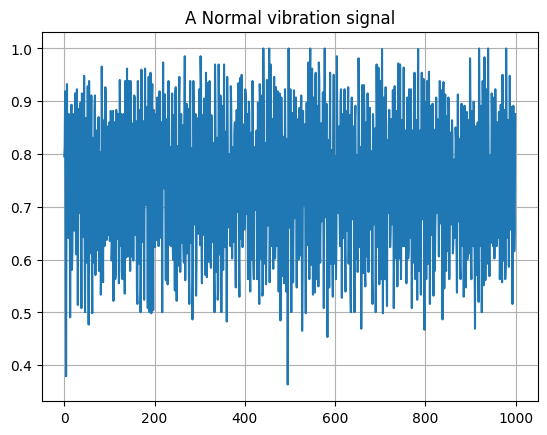

In [9]:
#Plotting sample of normal data
plt.grid()
plt.plot(np.arange(1000), normal_train_data[0])
plt.title("A Normal vibration signal")
plt.show()

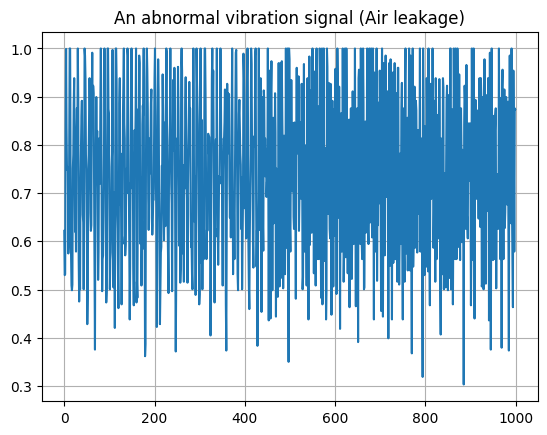

In [10]:
#Plotting sample of anomalous data
plt.grid()
plt.plot(np.arange(1000), anomalous_train_data[0])
plt.title("An abnormal vibration signal (Air leakage)")
plt.show()

In [12]:
#Creating the artificial neural network using Autoencoder
EMBEDDING_SIZE = 64 #Define how many neurons in the inner layer   <-----------------------------------------------------------------------------
class AnomalyDetector(Model):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Dense(32, activation="relu"),
      layers.Dense(16, activation="relu"),
      layers.Dense(EMBEDDING_SIZE, activation="relu")]) # Smallest Layer Defined Here

    self.decoder = tf.keras.Sequential([
      layers.Dense(16, activation="relu"),
      layers.Dense(32, activation="relu"),
      layers.Dense(1000, activation="sigmoid")])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AnomalyDetector()
print("Chosen Embedding Size: ", EMBEDDING_SIZE)

autoencoder.compile(optimizer='adam', loss='mae')
#Training the model.
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=200,
          batch_size=200,
          validation_data=(test_data, test_data),
          shuffle=True)

Chosen Embedding Size:  64
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 811ms/step - loss: 0.2426 - val_loss: 0.2424
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - loss: 0.2394 - val_loss: 0.2365
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.2315 - val_loss: 0.2252
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.2168 - val_loss: 0.2070
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.1944 - val_loss: 0.1844
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1689 - val_loss: 0.1653
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.1498 - val_loss: 0.1542
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.1386 - val_loss: 0.1446
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.1270 - val_loss: 0.1328
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - loss: 0.1141 - val_loss: 0.1247
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.1068 - val_loss: 0.1224
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 

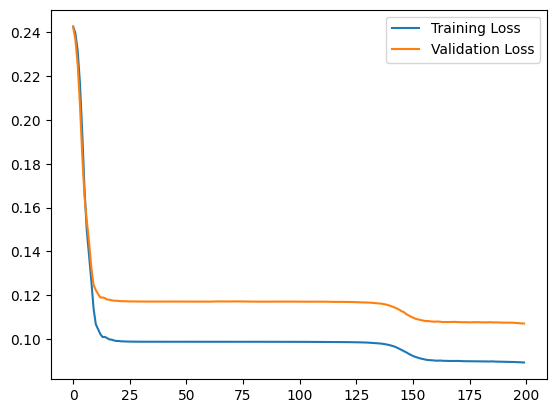

In [13]:
#Plotting the evolution of training and validation loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

How are the loss functions looking? Is there a need to adjust the EMBEDDING SIZE or the epochs in order to minimize it more?

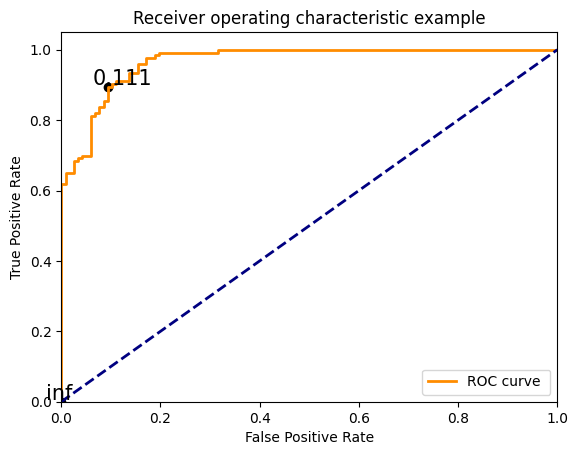

In [14]:
#Plotting True positive and false positive rate assessment
reconstructions = autoencoder(test_data)
loss = tf.keras.losses.mae(reconstructions, test_data)
fpr = []
tpr = []
#the test labels are flipped to match how the roc_curve function expects them.
flipped_labels = 1-test_labels
fpr, tpr, thresholds = roc_curve(flipped_labels, loss)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve ')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

# plot some thresholds
thresholds_every=20
thresholdsLength = len(thresholds)
colorMap=plt.get_cmap('jet', thresholdsLength)
for i in range(0, thresholdsLength, thresholds_every):
  threshold_value_with_max_four_decimals = str(thresholds[i])[:5]
  plt.scatter(fpr[i], tpr[i], c='black')
  plt.text(fpr[i] - 0.03, tpr[i] + 0.005, threshold_value_with_max_four_decimals, fontdict={'size': 15});

plt.show()

In [15]:
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.9671322354249183


In [17]:
threshold = 0.111 #Assign a value labeled in black in the ROC graph   <-----------------------------------------------------------------------------
def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold), loss

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

preds, scores = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.9
Precision = 0.8907563025210085
Recall = 0.905982905982906


### Task 3.1
How can you compare the models using data from the X-axis and Y-axis data? which one does a better job classifying? Explain your reasoning.



---

The Y-axis data does a much better job of classifying since it actually shows a knee in the ROC plot and varies with the embedding size.

---


##Working in the Z-axis

Recycle the code from the previous two dimensions, to build a model using the data from the Z-axis.

Chosen Embedding Size:  64
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.1596 - val_loss: 0.0976
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0816 - val_loss: 0.0681
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0629 - val_loss: 0.0661
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0612 - val_loss: 0.0652
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0610 - val_loss: 0.0650
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step - loss: 0.0609 - val_loss: 0.0648
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - loss: 0.0606 - val_loss: 0.0645
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0603 - val_loss: 0.0642
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 0.0599 - val_loss: 0.0642
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 0.0598 - val_loss: 0.0642
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s

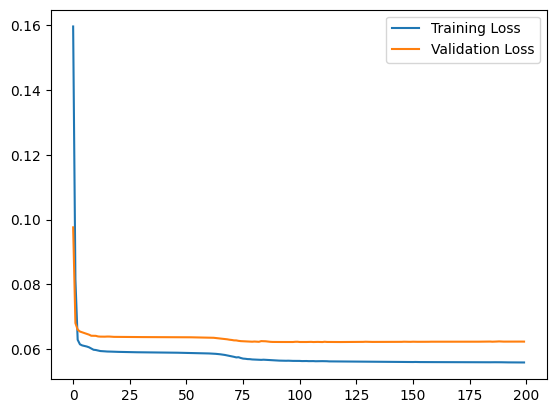

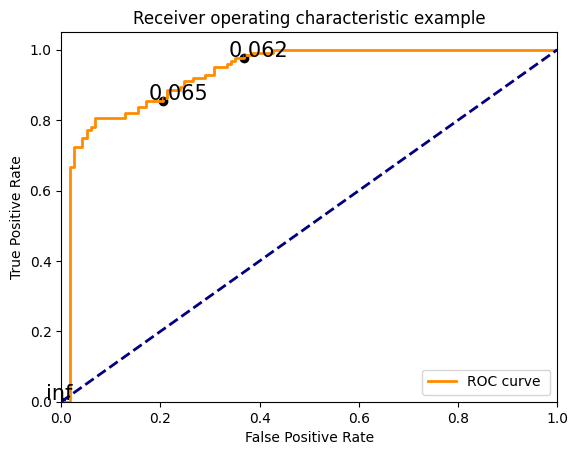

In [19]:
#Your code here

AXIS = 'Zacc array [m/s2]' #Pick and write the axis you want to work <-----------------------------------------------------------------------------

#Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat([df['Condition'],df[AXIS].str.split(' ', expand=True).astype(float)], axis=1)
ds = df_new.copy()
#Converting the Classifier into binary values
ds.loc[df['Condition'] == 'Vacuuming', 'Status'] = 1
ds.loc[df['Condition'] == 'Air_leakage', 'Status'] = 0
ds.drop('Condition', axis=1, inplace=True)

#Data transformation

raw_data = ds.values
# The last element contains the labels
labels = raw_data[:, -1]

# The other data points are the vacuum accelerometer data
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)
#Normalizing the values of the dataset
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)
#Splitting the dataset based on classification: train_labels: Vacuuming, ~train_labels: Air Leakage
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

portion_of_anomaly_in_training = 0.1 #10% of training data will be anomalies
end_size = int(len(normal_train_data)/(10-portion_of_anomaly_in_training*10))
combined_train_data = np.append(normal_train_data, anomalous_test_data[:end_size], axis=0)
combined_train_data.shape

# Anomaly Detector

autoencoderZ = AnomalyDetector()
print("Chosen Embedding Size: ", EMBEDDING_SIZE)

autoencoderZ.compile(optimizer='adam', loss='mae')
#Training the model.
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=200,
          batch_size=200,
          validation_data=(test_data, test_data),
          shuffle=True)

#Plotting the evolution of training and validation loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

#Plotting True positive and false positive rate assessment
reconstructions = autoencoderZ(test_data)
loss = tf.keras.losses.mae(reconstructions, test_data)
fpr = []
tpr = []
#the test labels are flipped to match how the roc_curve function expects them.
flipped_labels = 1-test_labels
fpr, tpr, thresholds = roc_curve(flipped_labels, loss)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve ')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

# plot some thresholds
thresholds_every=20
thresholdsLength = len(thresholds)
colorMap=plt.get_cmap('jet', thresholdsLength)
for i in range(0, thresholdsLength, thresholds_every):
  threshold_value_with_max_four_decimals = str(thresholds[i])[:5]
  plt.scatter(fpr[i], tpr[i], c='black')
  plt.text(fpr[i] - 0.03, tpr[i] + 0.005, threshold_value_with_max_four_decimals, fontdict={'size': 15});

plt.show()

#

In [21]:
threshold = 0.062 #Assign a value labeled in black in the ROC graph   <-----------------------------------------------------------------------------
def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold), loss

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

preds, scores = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.8625
Precision = 0.875
Recall = 0.8376068376068376


### Task 3.2
Which model (X, Y, or Z) would you choose to classify normal and abnormal readings for the vacuum problem? Explain your reasoning.



---

I would choose a Y-axis model to classify normal and abnormal readings for the vacuum problem, since I was able to generate a proper ROC plot with this dataset as opposed to the X-axis model, and it proved to be more accurate and have more precision and recall when compared to the Z-axis model.

---


### Task 3.3
What other data transformations/extractions would you consider to build a model to classify normal and abnormal data on the vacuum problem?



---

To build a model to classify normal and abnormal data I would also consider taking sound frequency data from a microphone placed near the vacuum. I would also want to compare the pressure or airflow at either end of the pump in both the air leak or normal operation.

---


<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)